In [249]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer
import transformers
from TurboQ.TQCache import TurboQuantCache
from TurboQ.TurboQuantOperations import TurboQuantMSE, TurboQuantResidual
import gc

In [137]:
seed = 10000
d = 10
rng = torch.Generator(device='cpu')
rng.manual_seed(seed)
tensor = torch.randn(d, generator=rng, dtype=torch.float32)
print(tensor)
print(tensor.to(dtype=torch.uint8))

tensor([ 2.0065,  1.9535,  0.1517, -0.4269, -0.5059, -0.7723,  2.9907,  0.4361,
         1.2058,  0.4792])
tensor([2, 1, 0, 0, 0, 0, 2, 0, 1, 0], dtype=torch.uint8)


In [36]:
import os
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"]="60"
os.environ["HF_HUB_DISABLE_XET"] = "1"

In [37]:
try:
    del model
except:
    print("Model not loaded yet")
try:
    del tokenizer
except:
    print("Tokenizer not loaded yet")
torch.cuda.empty_cache()
gc.collect()

2330

In [38]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-3B-Instruct')

In [39]:
model = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2.5-3B-Instruct', output_attentions=True).to('cuda')

Loading weights: 100%|██████████| 434/434 [00:00<00:00, 3784.69it/s]


In [131]:
text = """You are reviewing a mountaineering expedition roster. Read the following team log carefully, then answer the question at the end using only the information provided. Give the exact numeric answer and briefly show your work.

--- EXPEDITION ROSTER ---

1. Elena Rourke — Lead Guide — Oxygen tank reading: 3120 PSI — Assigned: Camp II — Day 4 on mountain.
2. Marcus Voss — Cook — Oxygen tank reading: 2955 PSI — Assigned: Base Camp — Day 1 on mountain.
3. Priya Anand — Climber — Oxygen tank reading: 2840 PSI — Assigned: Camp III — Day 6 on mountain.
4. Jonas Kessler — Medic — Oxygen tank reading: 3310 PSI — Assigned: Camp I — Day 3 on mountain.
5. Lila Anand — Photographer — Oxygen tank reading: 2705 PSI — Assigned: Base Camp — Day 2 on mountain.
6. Devon Okafor — Climber — Oxygen tank reading: 3005 PSI — Assigned: Camp II — Day 5 on mountain.
7. Priya Nandwani — Climber — Oxygen tank reading: 2999 PSI — Assigned: Camp III — Day 7 on mountain.
8. Tomas Bergen — Radio Operator — Oxygen tank reading: 2860 PSI — Assigned: Camp I — Day 4 on mountain.
9. Ingrid Solheim — Climber — Oxygen tank reading: 3150 PSI — Assigned: Camp III — Day 8 on mountain.
10. Marcus Vance — Guide — Oxygen tank reading: 2900 PSI — Assigned: Base Camp — Day 2 on mountain.
11. Yusuf Demir — Climber — Oxygen tank reading: 3080 PSI — Assigned: Camp II — Day 6 on mountain.
12. Rosalind Kessner — Climber — Oxygen tank reading: 1965 PSI — Assigned: Camp IV — Day 9 on mountain.
13. Anders Fjeld — Cook — Oxygen tank reading: 2775 PSI — Assigned: Base Camp — Day 3 on mountain.
14. Priya Chandrasekaran — Medic — Oxygen tank reading: 3020 PSI — Assigned: Camp I — Day 5 on mountain.

--- END ROSTER ---

Question: What is the sum, in PSI, of the oxygen tank readings for Priya Anand and Rosalind Kessner?"""

In [314]:
from transformers.cache_utils import DynamicCache
crazy = 0
def inference(prompt):
    # text = input("Enter Query: ")
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]
    streamer = TextStreamer(tokenizer)
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True    
    )
    TurboCache = TurboQuantCache(
        device=model.device, 
        num_key_heads=model.config.num_key_value_heads,
        dim=128,
        key_quantizer=TurboQuantMSE,
        value_quantizer=TurboQuantMSE,
        vquant_size=4,
        config=model.config,
        kquant_size=8,
    )
    encoded = tokenizer(text, return_tensors='pt').to('cuda')
    model.eval()
    print("Starting inference\n")
    with torch.no_grad():
        output = model.generate(
            **encoded,
            max_new_tokens=200,
            temperature=0.8,
            pad_token_id=tokenizer.eos_token_id,
            past_key_values=TurboCache,
            use_cache=True, 
            return_dict_in_generate=True,
            streamer=streamer
        )
        print(type(output.past_key_values))
        print(output.past_key_values)
        print(f"Final tokens: {output}")

        global crazy
        crazy = output.past_key_values    
        return tokenizer.decode(
            output[0],
            skip_special_tokens=True
        )

In [315]:
import importlib
import TurboQ
import TurboQ.Sero as TQ
importlib.reload(TQ)
importlib.reload(TurboQ.TQCache)
importlib.reload(TurboQ.TurboQuantOperations)
importlib.reload(TurboQ.rotations)

<module 'TurboQ.rotations' from 'c:\\MeepMeep\\New folder\\turboQuant\\TurboQ\\rotations.py'>

In [316]:
model.config.num_key_value_heads

2

In [317]:
encoded = tokenizer(text, return_tensors='pt')
print(encoded['input_ids'].shape)

torch.Size([1, 531])


In [318]:
# output = inference(text)
output = inference("Give me c++  to print hello world.")
print(output[0])

Initializing Key Quantizer:<class 'TurboQ.TurboQuantOperations.TurboQuantMSE'>
tensor([[ 0.0266,  0.0355,  0.0741,  ...,  0.0847, -0.1355,  0.0425],
        [-0.0003,  0.0587,  0.1706,  ..., -0.0044, -0.1370,  0.0280],
        [-0.0420,  0.0373, -0.0417,  ...,  0.1318, -0.0175,  0.0476],
        ...,
        [ 0.0024,  0.1096,  0.1086,  ...,  0.0210, -0.1510, -0.0226],
        [-0.0315,  0.0640,  0.1582,  ..., -0.0255, -0.0391,  0.1425],
        [ 0.1088, -0.0100,  0.0764,  ..., -0.0634,  0.0290, -0.0074]],
       device='cuda:0')
Initializing Value Quantizer:<class 'TurboQ.TurboQuantOperations.TurboQuantMSE'>
tensor([[ 0.0266,  0.0355,  0.0741,  ...,  0.0847, -0.1355,  0.0425],
        [-0.0003,  0.0587,  0.1706,  ..., -0.0044, -0.1370,  0.0280],
        [-0.0420,  0.0373, -0.0417,  ...,  0.1318, -0.0175,  0.0476],
        ...,
        [ 0.0024,  0.1096,  0.1086,  ...,  0.0210, -0.1510, -0.0226],
        [-0.0315,  0.0640,  0.1582,  ..., -0.0255, -0.0391,  0.1425],
        [ 0.1088, -

In [119]:
for name, param in model.named_parameters():
    print(name)

model.embed_tokens.weight
model.layers.0.self_attn.q_proj.weight
model.layers.0.self_attn.q_proj.bias
model.layers.0.self_attn.k_proj.weight
model.layers.0.self_attn.k_proj.bias
model.layers.0.self_attn.v_proj.weight
model.layers.0.self_attn.v_proj.bias
model.layers.0.self_attn.o_proj.weight
model.layers.0.mlp.gate_proj.weight
model.layers.0.mlp.up_proj.weight
model.layers.0.mlp.down_proj.weight
model.layers.0.input_layernorm.weight
model.layers.0.post_attention_layernorm.weight
model.layers.1.self_attn.q_proj.weight
model.layers.1.self_attn.q_proj.bias
model.layers.1.self_attn.k_proj.weight
model.layers.1.self_attn.k_proj.bias
model.layers.1.self_attn.v_proj.weight
model.layers.1.self_attn.v_proj.bias
model.layers.1.self_attn.o_proj.weight
model.layers.1.mlp.gate_proj.weight
model.layers.1.mlp.up_proj.weight
model.layers.1.mlp.down_proj.weight
model.layers.1.input_layernorm.weight
model.layers.1.post_attention_layernorm.weight
model.layers.2.self_attn.q_proj.weight
model.layers.2.self

In [ ]:
h = torch.zeros(3,3).to('cuda')

In [34]:
x = 10
tensor = torch.arange(0,x).reshape(2,5)
ls = torch.tensor([i*10 for i in range(0, x)])
x = ls[tensor[...,:]].to(dtype=torch.float32)
print(x.shape)
x_norms = x.norm(dim=-1)
print(x_norms)

torch.Size([2, 5])
tensor([ 54.7723, 159.6872])


In [ ]:
def hook(module, input, output):
    global h
    h = output

In [ ]:
crazy.layers[0].keys.mse_indices.shape

torch.Size([1, 2, 78, 64])

In [ ]:
print(f"Qwen2 File:, {transformers.models.qwen2.modeling_qwen2.__file__}")

Qwen2 File:, c:\Users\vanir\miniconda3\envs\moeLoRA\lib\site-packages\transformers\models\qwen2\modeling_qwen2.py


In [ ]:
print(model.config.num_attention_heads)      # query heads
print(model.config.num_key_value_heads)      # KV heads (GQA)
print(model.config.hidden_size)              # 2048
print(model.config.hidden_size // model.config.num_attention_heads)  # head_dim

16
2
2048
128


In [54]:
with open('model_config.txt', 'w') as f:
    f.write(str(model.config))
f.close()

In [55]:
print(model.config.num_attention_heads)     # e.g. 32
model.config.num_key_value_heads     # should be 2, matching your cache

16


2

In [56]:
a = torch.Tensor([[1],[4]])

In [57]:
vec = crazy.layers[11].keys

In [58]:
for i in range(0,32):
    print(f"{i}. {torch.max(crazy.layers[i].keys[0])}, avg: {torch.mean(crazy.layers[i].keys[0])} from shape: {crazy.layers[i].keys[0].shape}")

RuntimeError: mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Byte

In [ ]:
from scipy.stats import kstest

In [ ]:
from TurboQ.TurboQuantOperations import TurboQuantOps
ops = TurboQuantOps()

In [ ]:
n = 128
b = torch.empty([1,1,1,n], device='cuda')
b = b.random_(0,2)
b[b == 0] = -1

In [ ]:
c = torch.empty([1,1,1,n], device='cuda')
c = c.random_(0,2)
c[c == 0] = -1

In [ ]:
r = b*vec
r_rot = ops.FWHT(r, normalize=True)
# r_rot = r
r_rot.shape

Gonna normalize


torch.Size([1, 2, 2899, 128])

In [ ]:
f = c*r_rot
f_rot = ops.FWHT(f, normalize=True)
# f_rot = f
# f_rot.shape

Gonna normalize


In [ ]:
import matplotlib.pyplot as plt

(array([0.02415059, 0.06037647, 0.04830117, 0.10867764, 0.09660235,
        0.24150587, 0.25358117, 0.18112941, 0.14490352, 0.1932047 ,
        0.09660235, 0.09660239]),
 array([-4.25454712, -3.60756493, -2.96058273, -2.31360054, -1.66661835,
        -1.01963615, -0.37265396,  0.27432823,  0.92131042,  1.56829262,
         2.21527481,  2.862257  ,  3.50923896]),
 <BarContainer object of 12 artists>)

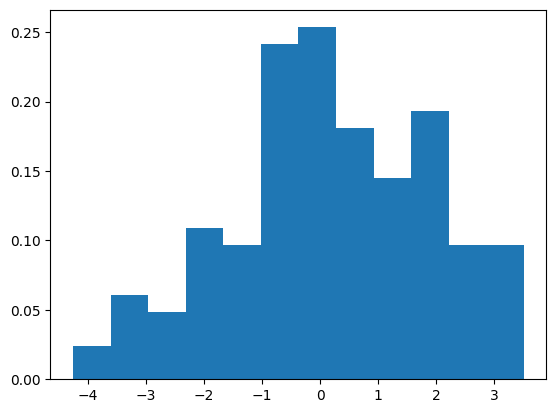

In [ ]:
plt.hist(f_rot[0][0][2000].flatten().to(torch.float32).cpu().numpy(), bins=12, density=True)

In [ ]:
import torch
from scipy.stats import kstest
from joblib import Parallel, delayed
import multiprocessing as mp
import math

# 1. Update the function to accept the 4th argument: dist_args
def single_ks_test(idx, sample, dist, dist_args):
    """Run one Kolmogorov-Smirnov test."""
    # 2. Pass dist_args into the kstest function
    result = kstest(sample, dist, args=dist_args)
    return idx, result.statistic, result.pvalue

dist = "norm"
n_cores = mp.cpu_count()
print(f"Using {n_cores} CPU cores")
# Assuming f_rot is defined in your notebook
args_list = []
for i in range(f_rot.shape[-2]): # Adjust your range
    sample = f_rot[0][0][i].flatten().to(torch.float32).cpu().numpy().copy()
    
    # Calculate the standard deviation just for this specific sample
    sample_sigma = sample.std() 
    
    # Pass this specific scalar to the arguments (4 elements total)
    args_list.append((i, sample, dist, (0, sample_sigma)))
        
# 3. Update the Joblib loop to unpack and pass all 4 variables
results = Parallel(n_jobs=n_cores)(
    delayed(single_ks_test)(idx, sample, dist, dist_args) 
    for idx, sample, dist, dist_args in args_list
)

failures = 0
dsum = 0
for i in results:
    if i[2] < 0.05:
        dsum += i[1]
        failures += 1 
print(f"Total Failures: {failures} out of {f_rot.shape[-2]}")
print(f"AVG Dsum: {dsum/failures}")

Using 16 CPU cores
Total Failures: 177 out of 2899
AVG Dsum: 0.12965215024534846
